Relatório Executivo: Desempenho de Vendas Olist
1. Introdução
O Olist consolidou-se como um ecossistema líder em soluções de tecnologia e logística para o varejo moderno, atuando como um facilitador estratégico para empresas que buscam expansão acelerada nos canais digitais. Fundada em 2015 em Curitiba por Tiago Dalvi, a companhia opera como um "sistema operacional" para o comércio, transacionando aproximadamente R$ 5 bilhões por mês e atendendo a uma base de mais de 270 mil usuários e 50 mil empresas ativas.

Através de um modelo de negócio robusto que integra plataforma de e-commerce (Vnda), sistema de gestão ERP (Tiny) e soluções logísticas próprias (PAX), o Olist remove barreiras de entrada e complexidades operacionais. Sua proposta de valor reside na centralização da gestão de vendas e na conexão direta com mais de 40 marketplaces, permitindo que seus parceiros alcancem escala competitiva e eficiência financeira em um cenário de varejo omnichannel cada vez mais complexo. Em 2021, o ecossistema alcançou o status de unicórnio, sendo avaliado em US$ 1,2 bilhão.

2. Contexto
Este relatório apresenta uma visão consolidada do desempenho comercial da Olist, destacando a concentração geográfica das vendas, as categorias de produtos mais rentáveis e a trajetória de crescimento mensal da plataforma entre 2016 e 2018.

Os dados analisados compõem o ecossistema de e-commerce brasileiro, integrando informações de pedidos, pagamentos, clientes e produtos. Foram processados mais de 119 mil registros após limpeza e tratamento de variáveis temporais e financeiras.


In [42]:
# manipulação de Dados
import pandas as pd
import numpy as np

# visualiazação dos Dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


# Lista de datasets a serem carregados
df_customers = pd.read_csv('olist_customers_dataset.csv', sep=',')
df_order_items = pd.read_csv('olist_order_items_dataset.csv', sep=',')
df_order_pay = pd.read_csv('olist_order_payments_dataset.csv', sep=',')
df_orders_dt = pd.read_csv('olist_orders_dataset.csv', sep=',')
df_prod_dt = pd.read_csv('olist_products_dataset.csv', sep=',')
df_sellers_dt = pd.read_csv('olist_sellers_dataset.csv', sep=',')
df_order_rw = pd.read_csv('olist_order_reviews_dataset.csv', sep=',', quotechar='"', on_bad_lines='skip')
df_geolocation = pd.read_csv('olist_geolocation_dataset.csv', sep=',')
df_product_category_name_translation = pd.read_csv('product_category_name_translation.csv', sep=',')

In [43]:
#Explorando o dataset
df_orders_dt.info()
df_order_items.info()
df_customers.info()
df_sellers_dt.info()
df_order_pay.info()
df_prod_dt.info()
df_order_rw.info()
df_geolocation.info()
df_product_category_name_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 

In [44]:
df_orders_dt.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [45]:
#Construção do Modelo Analítico Consolidado
df_conso = df_orders_dt.merge(df_customers, on='customer_id', how='left')
df_conso = df_conso.merge(df_order_items, on='order_id', how='left')
df_conso = df_conso.merge(df_prod_dt, on='product_id', how='left')
df_conso = df_conso.merge(df_sellers_dt, on='seller_id', how='left')
df_conso = df_conso.merge(df_order_pay, on='order_id', how='left')
df_conso = df_conso.merge(df_order_rw, on='order_id', how='left')
df_conso = df_conso.merge(df_product_category_name_translation, on='product_category_name', how='left')
display(df_conso.head())
print(f"Olist dataset consolidado: {df_conso.shape}")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


Olist dataset consolidado: (119143, 40)


In [46]:
df_conso.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [47]:
# Converter colunas de data para datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_columns:
    if col in df_conso.columns:
        df_conso[col] = pd.to_datetime(df_conso[col], errors='coerce')

print("Conversão de datas concluída. Info do DataFrame master:")
df_conso.info()


Conversão de datas concluída. Info do DataFrame master:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_cit

Analise e Interpretacao dos dados do dataset consolidado Olist

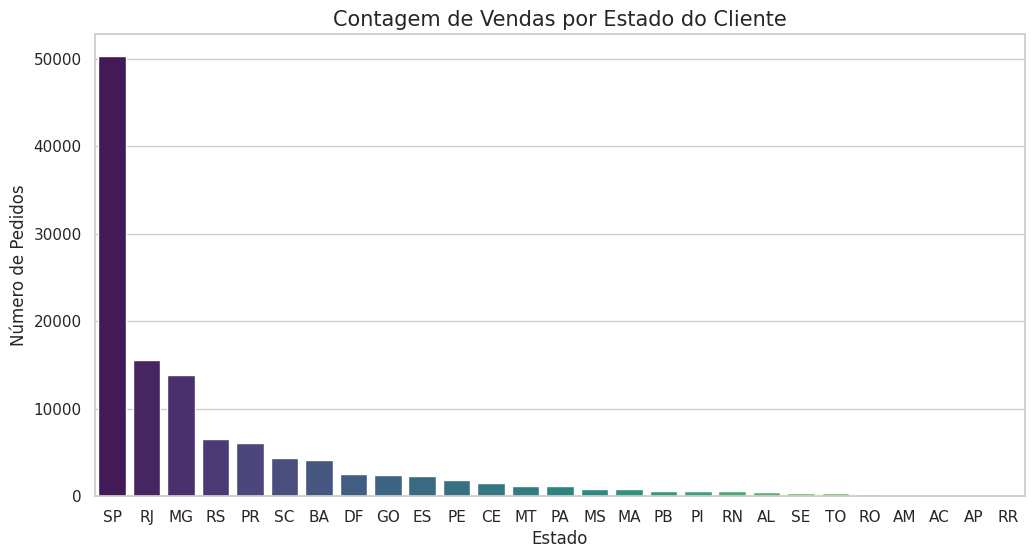

In [48]:
#Numero de Pedidos e Faturamento por Estado do Cliente

# Configurações de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Criando o gráfico de contagem por estado
order_count_by_state = df_conso['customer_state'].value_counts().reset_index()
order_count_by_state.columns = ['state', 'count']

sns.barplot(data=order_count_by_state, x='state', y='count', palette='viridis', hue='state', legend=False)

plt.title('Contagem de Vendas por Estado do Cliente', fontsize=15)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.xticks(rotation=0)
plt.show()

,Estado,Faturamento_Total
0,SP,7726078.35
1,RJ,2795615.67
2,MG,2351221.09
3,RS,1160175.66
4,PR,1079795.49
5,BA,805070.98
6,SC,801276.45
7,GO,520481.65
8,DF,438095.32
9,ES,408611.64


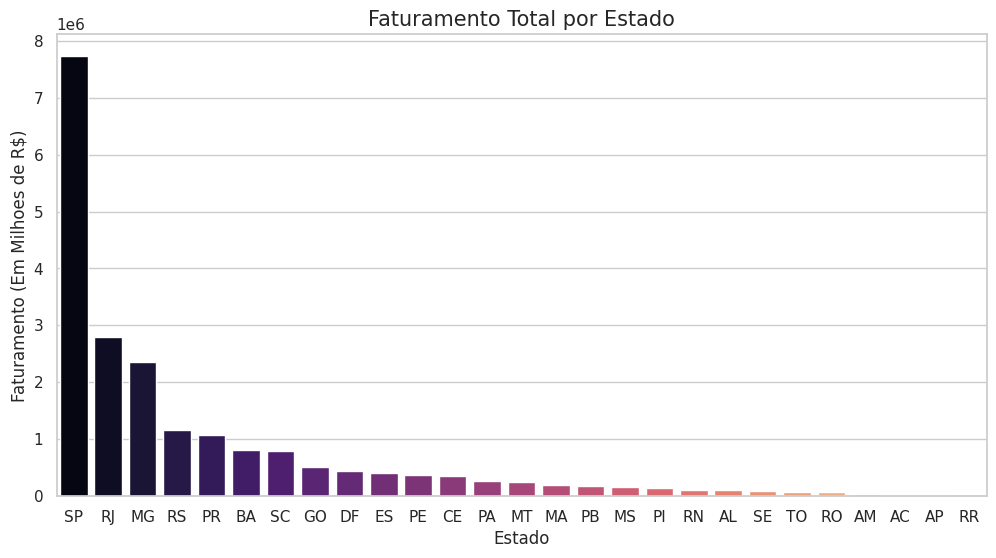

In [49]:
# Garantindo que payment_value seja numérico
if df_conso['payment_value'].dtype == 'object':
    # Limpando caracteres de formatação
    clean_values = df_conso['payment_value'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    # Convertendo para numérico, transformando erros (como ' - ') em NaN
    df_conso['payment_value'] = pd.to_numeric(clean_values, errors='coerce')

# Calculando o faturamento total por estado
faturamento_estado = df_conso.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).reset_index()
faturamento_estado.columns = ['Estado', 'Faturamento_Total']

# Exibindo o resultado
display(faturamento_estado)

# Visualização
plt.figure(figsize=(12, 6))
sns.barplot(data=faturamento_estado, x='Estado', y='Faturamento_Total', palette='magma', hue='Estado', legend=False)
plt.title('Faturamento Total por Estado', fontsize=15)
plt.ylabel('Faturamento (Em Milhoes de R$)', fontsize=12)
plt.show()

A análise geográfica revela uma forte concentração de mercado, característica do e-commerce brasileiro:

Dominância do Sudeste: O estado de São Paulo (SP) é o motor principal da Olist, concentrando o maior volume de pedidos e gerando aproximadamente R$ 7,72 milhões em faturamento.
Top 3 Estratégico: São Paulo, Rio de Janeiro e Minas Gerais compõem a base mais sólida de clientes, evidenciando que a logística e o esforço de marketing na região Sudeste trazem o maior retorno financeiro direto.
Correlação Direta: Observa-se uma correlação quase perfeita entre o número de pedidos e o faturamento por estado. Isso indica um ticket médio relativamente estável entre as regiões, onde o aumento do volume de transações é o principal driver para o crescimento da receita em novos mercados.


*   Dominância do Sudeste: O estado de São Paulo (SP) é o motor principal da Olist, concentrando o maior volume de pedidos e gerando aproximadamente R$ 7,72 milhões em faturamento.

*   Top 3 Estratégico: São Paulo, Rio de Janeiro e Minas Gerais compõem a base mais sólida de clientes, evidenciando que a logística e o esforço de marketing na região Sudeste trazem o maior retorno financeiro direto.

*   Correlação Direta: Observa-se uma correlação quase perfeita entre o número de pedidos e o faturamento por estado. Isso indica um ticket médio relativamente estável entre as regiões, onde o aumento do volume de transações é o principal driver para o crescimento da receita em novos mercados.


Oportunidade: Existe um vasto potencial de expansão para as regiões Sul e Nordeste (lideradas por RS, PR e BA), onde a presença já é relevante, mas ainda distante dos volumes registrados no eixo SP-RJ.```

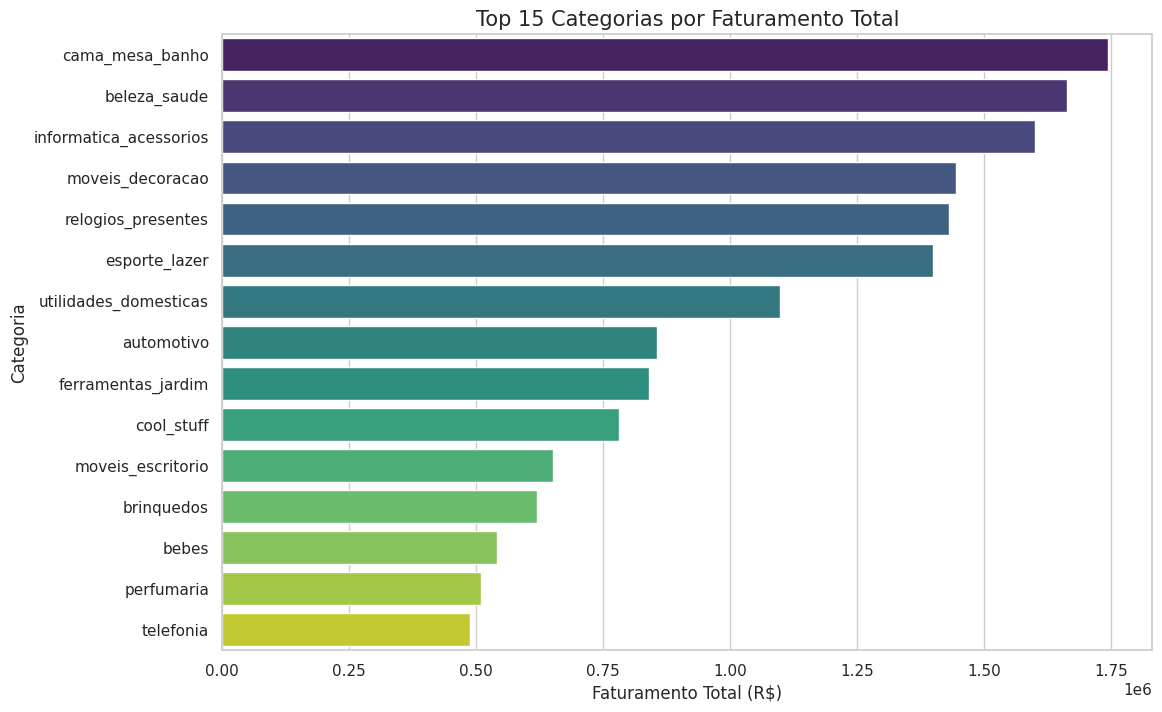

,Categoria,Faturamento_Total
0,cama_mesa_banho,1743998.80
1,beleza_saude,1662963.59
2,informatica_acessorios,1599481.06
3,moveis_decoracao,1443963.61
4,relogios_presentes,1430553.48
5,esporte_lazer,1400223.07
6,utilidades_domesticas,1097900.09
7,automotivo,855095.68
8,ferramentas_jardim,840721.59
9,cool_stuff,781933.97


In [50]:
#Faturamemto por Categoria
fatu_cat = df_conso.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).reset_index()
fatu_cat.columns = ['Categoria', 'Faturamento_Total']

# Selecionando as top 15 categorias para o gráfico
top_15cat = fatu_cat.head(15)

# Visualização
plt.figure(figsize=(12, 8))
sns.barplot(data=top_15cat, y='Categoria', x='Faturamento_Total', palette='viridis', hue='Categoria', legend=False)

plt.title('Top 15 Categorias por Faturamento Total', fontsize=15)
plt.xlabel('Faturamento Total (R$)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.show()

# Dados brutos das top 10
display(fatu_cat.head(10))

A análise das categorias de produtos revela uma concentração saudável de receita em nichos de alta recorrência e valor agregado:

Liderança em Utilidades e Bem-Estar: As categorias de 'Cama, Mesa e Banho', 'Beleza e Saúde' e 'Informática e Acessórios' dominam o topo do ranking. Juntas, elas representam os pilares de faturamento da plataforma, indicando um perfil de consumidor focado em itens essenciais e melhoria do ambiente doméstico.
Itens de Alto Valor (High-Ticket): A presença marcante de 'Relógios e Presentes' e 'Móveis e Decoração' entre as cinco maiores categorias sugere que a Olist é um destino confiável para compras de maior valor unitário, não se limitando apenas a produtos de baixo custo.
Diversidade do Mix: O faturamento é distribuído por uma ampla gama de categorias, o que reduz a dependência de um único setor e confere maior resiliência financeira à operação diante de oscilações específicas de mercado.
Conclusão: O mix de produtos atual está bem alinhado com as demandas do e-commerce moderno. Estratégias de cross-selling entre as categorias líderes (ex: móveis e decoração) podem potencializar ainda mais o ticket médio.

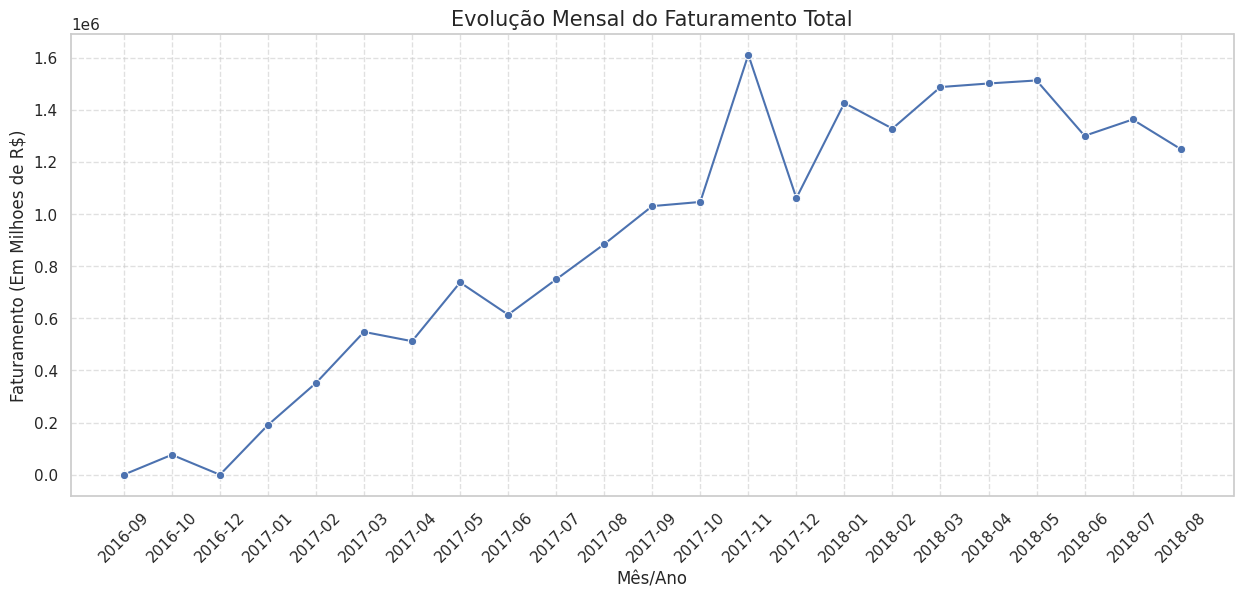

,month_year,payment_value
20,2018-06,1299683.17
21,2018-07,1362267.08
22,2018-08,1248942.63
23,2018-09,4439.54
24,2018-10,589.67


In [51]:
#Evolução Mensal Faturamento

# Criando uma coluna de Mês/Ano para a evolução temporal
df_conso['month_year'] = df_conso['order_purchase_timestamp'].dt.to_period('M')

# Agrupando faturamento por mês
faturamento_mes = df_conso.groupby('month_year')['payment_value'].sum().reset_index()

# Convertendo Period para string para facilitar a visualização no gráfico
faturamento_mes['month_year'] = faturamento_mes['month_year'].astype(str)

# Excluindo os 2 últimos para o gráfico
faturamento_mes_fil = faturamento_mes.iloc[:-2]

# Visualização
plt.figure(figsize=(15, 6))
sns.lineplot(data=faturamento_mes_fil, x='month_year', y='payment_value', marker='o', color='b')

plt.title('Evolução Mensal do Faturamento Total', fontsize=15)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Faturamento (Em Milhoes de R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Exibindo os últimos meses do DataFrame original (para referência)
display(faturamento_mes.tail())

A análise da trajetória temporal do faturamento da Olist revela três fases distintas:

Freio e Retomada (Jan/2017): Após um breve período de estagnação no final de 2016, houve um salto significativo em janeiro de 2017, marcando o início de uma tendência de alta consistente.
Expansão Acelerada (2017 - meados de 2018): A plataforma apresentou um crescimento robusto, atingindo picos superiores a R$ 1,5 milhão por mês em maio de 2018. Note-se um pico excepcional em Novembro de 2017, provavelmente impulsionado pela Black Friday.
Observação: Os dados de setembro e outubro de 2018 foram removidos da visualização principal por estarem incompletos no dataset, o que poderia distorcer a percepção de crescimento real da operação.

,payment_type,count,percentage
0,credit_card,87776,73.674668
1,boleto,23190,19.464496
2,voucher,6465,5.426389
3,debit_card,1706,1.431929


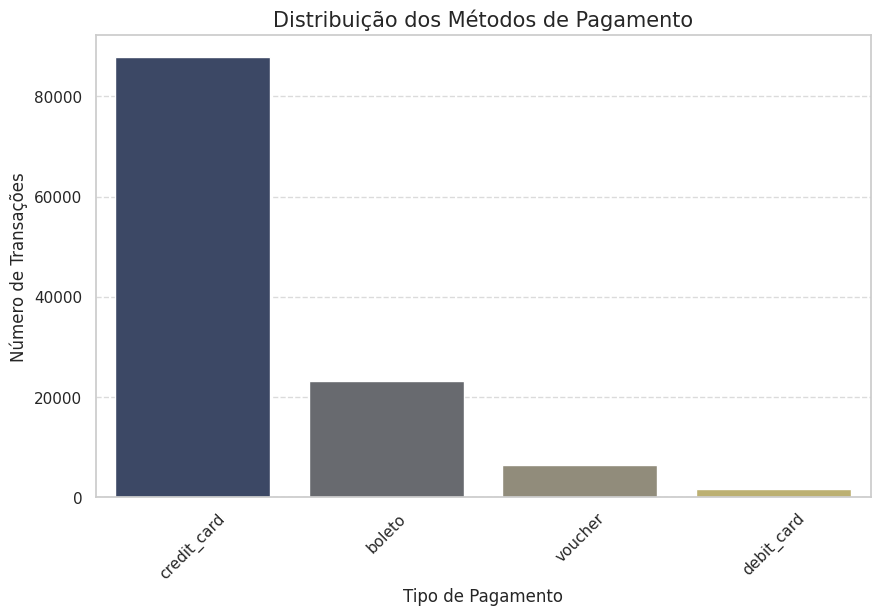

In [52]:
#Distribuição dos Métodos de Pagamento
# Contagem de cada tipo de pagamento
payment_counts = df_conso['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']

# Calculando a porcentagem
payment_counts['percentage'] = (payment_counts['count'] / payment_counts['count'].sum()) * 100

# Filtrando para não mostrar 'not_defined'
payment_counts = payment_counts[payment_counts['payment_type'] != 'not_defined']

# Exibindo os dados
display(payment_counts)

# Visualização
plt.figure(figsize=(10, 6))
sns.barplot(data=payment_counts, x='payment_type', y='count', palette='cividis', hue='payment_type', legend=False)
plt.title('Distribuição dos Métodos de Pagamento', fontsize=15)
plt.xlabel('Tipo de Pagamento', fontsize=12)
plt.ylabel('Número de Transações', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

,payment_type,payment_value
0,credit_card,15775450.54
1,boleto,4110920.74
2,voucher,435917.84
3,debit_card,257374.89


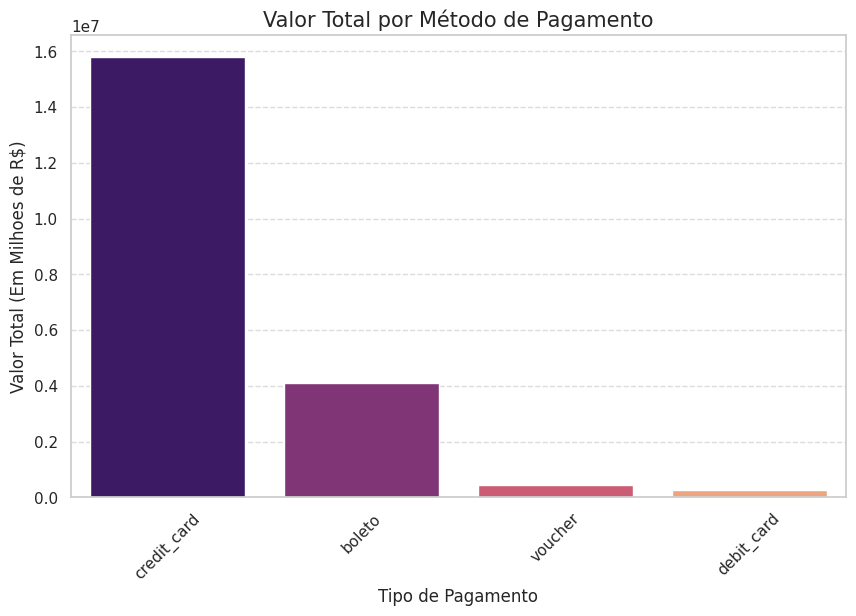

In [53]:
# Calculando o valor total por método de pagamento
payment_value_sum = df_conso.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False).reset_index()

# Filtrando para não mostrar 'not_defined'
payment_value_sum = payment_value_sum[payment_value_sum['payment_type'] != 'not_defined']

# Exibindo os valores
display(payment_value_sum)

# Visualização
plt.figure(figsize=(10, 6))
sns.barplot(data=payment_value_sum, x="payment_type", y="payment_value", palette="magma", hue="payment_type", legend=False)

plt.title("Valor Total por Método de Pagamento", fontsize=15)
plt.xlabel("Tipo de Pagamento", fontsize=12)
plt.ylabel("Valor Total (Em Milhoes de R$)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

A análise da distribuição e do volume financeiro por método de pagamento revela a predominância do crédito no e-commerce brasileiro:

Predomínio do Cartão de Crédito: O cartão de crédito é o método preferido, representando cerca de 73,6% das transações e 79% do volume financeiro total (aproximadamente R$ 15,7 milhões). Isso indica uma forte dependência de crédito e possivelmente do parcelamento para compras na plataforma.
Boleto Bancário como Segunda Força: O boleto retém uma fatia importante de 19,4% das vendas. É um método essencial para incluir consumidores que não possuem cartão ou preferem pagar à vista com segurança.
Voucher e Débito: Estes métodos somados representam menos de 7% do volume total, sugerindo que são formas de pagamento complementares ou utilizadas em nichos específicos de compra.
Conclusão: Estratégias de incentivo (como descontos no boleto) ou melhorias nas condições de parcelamento no cartão podem impactar diretamente o volume de vendas, dado o comportamento atual dos usuários.

Conclusão
Relatório Consolidado e Recomendações
Síntese dos Resultados
A análise do ecossistema Olist entre 2016 e 2018 revela uma operação em estágio de maturação acelerada, com fundamentos sólidos e uma clara dominância em mercados estratégicos.

Performance Financeira: O faturamento demonstrou crescimento exponencial, atingindo seu ápice em 2018. O pico histórico em Novembro de 2017 confirma a alta sensibilidade da plataforma a eventos sazonais de grande escala, como a Black Friday.
Geografia do Sucesso: A operação é altamente centralizada no Sudeste. São Paulo não é apenas o maior mercado, mas o motor que sustenta o volume transacional da plataforma (R$ 7,72M).
Perfil de Consumo: O consumidor da Olist busca principalmente itens de 'Cama, Mesa e Banho', 'Beleza e Saúde' e 'Informática'. A forte presença de itens de alto valor unitário (Relógios e Móveis) indica confiança na segurança da plataforma.
Comportamento de Pagamento: Existe uma dependência estrutural do cartão de crédito (79% do volume financeiro). O boleto permanece relevante para inclusão de uma parcela significativa da base.
Oportunidades Identificadas
Expansão Regional: Existe um um vasto potencial de expansão nas regiões Sul e Nordeste. O Paraná e o Rio Grande do Sul já possuem volume relevante, mas subestimado em comparação ao Sudeste.
Otimização de Mix: Categorias como 'Brinquedos' e 'Bebês' apresentam bom faturamento, mas podem ser alavancadas através de kits e vendas cruzadas com as categorias líderes.
Fidelização via Pagamento: A baixa utilização de cartão de débito e vouchers sugere que há espaço para programas de cashback ou parcerias com bancos digitais e carteiras de benefícios.
Recomendações Estratégicas
Logística Regionalizada: Para expandir fora do eixo SP-RJ sem comprometer a margem, recomenda-se a criação de centros de distribuição avançados ou parcerias logísticas locais no Sul e Nordeste, visando reduzir o frete (barreira comum no e-commerce).
Diversificação de Crédito: Explorar novas modalidades de pagamento, como o PIX (em um contexto atualizado) ou parcelamento no boleto, para capturar o público que não possui limite de crédito suficiente para itens de alto ticket.
Foco em Retenção: Dado que o custo de aquisição de clientes (CAC) tende a subir com a maturidade, implementar estratégias de CRM focadas nas categorias de alta recorrência (Beleza e Saúde) para aumentar o LTV (Lifetime Value).
Sazonalidade Antecipada: Preparar a infraestrutura logística e de suporte com 3 meses de antecedência para os picos de fim de ano, dado que o histórico mostra que a plataforma opera próxima ao limite de sua capacidade nestes períodos.